# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [2]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = 'data/raw'
processed_dir = 'data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

Synthetic dataset with two columns created and saved to data/raw/outliers_homework.csv


In [3]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [ ]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [5]:
import pandas as pd
import numpy as np

def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return boolean mask for IQR-based outliers.
    
    Improvements & Assumptions:
    - Validates that strictness parameter k > 0.
    - Handles empty Series cleanly without errors.
    - Missing values (NaN) evaluate to False in comparison operations (< or >).
    """
    if k <= 0:
        raise ValueError("Parameter k must be strictly positive (k > 0).")
    if series.empty:
        return pd.Series(dtype=bool, index=series.index)
        
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0, ddof: int = 1) -> pd.Series:
    """Return boolean mask for Z-score outliers where |z| > threshold.
    
    Improvements & Assumptions:
    - Validates that threshold > 0.
    - Uses sample standard deviation (ddof=1) by default instead of population std (ddof=0).
    - Prevents DivisionByZeroError if sample standard deviation is zero or NaN.
    - Missing values (NaN) result in NaN Z-scores, evaluating to False in threshold comparisons.
    """
    if threshold <= 0:
        raise ValueError("Threshold must be strictly positive (threshold > 0).")
    if series.empty:
        return pd.Series(dtype=bool, index=series.index)
        
    mu = series.mean()
    sigma = series.std(ddof=ddof)
    
    if sigma == 0 or pd.isna(sigma):
        return pd.Series(False, index=series.index)
        
    z = (series - mu) / sigma
    return z.abs() > threshold

*(Stretch)* A working `winsorize_series` is provided below. Improve it if you can - it does not check that `lower` is below `upper` - then use it in the comparison further down.

In [8]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    """Cap values below lower quantile and above upper quantile.
    
    Improvements:
    - Validates quantile parameter bounds (0 <= lower < upper <= 1).
    - Safely handles empty series.
    """
    if not (0 <= lower < upper <= 1):
        raise ValueError("Quantile parameters must satisfy 0 <= lower < upper <= 1.")
    if series.empty:
        return series.copy()
        
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

## Apply Detection and Create Flags (choose a numeric column)

In [9]:
target_col = 'y' if 'y' in df.columns else df.select_dtypes(include=['number']).columns[0]
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean()  # fraction flagged

outlier_iqr    0.078261
outlier_z      0.043478
dtype: float64

### Visual Checks (boxplot / histogram)

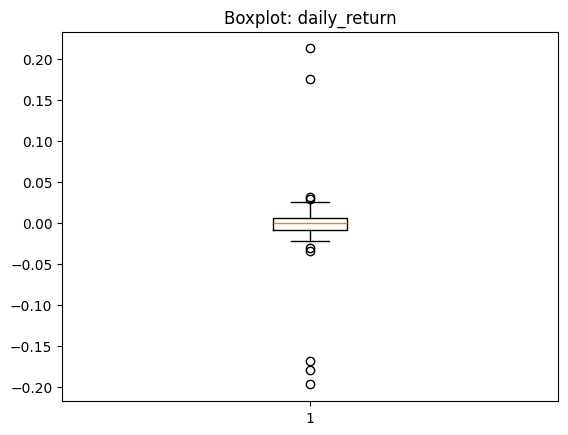

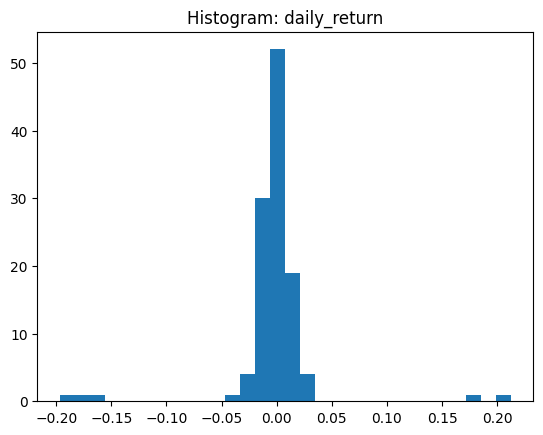

In [10]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [11]:
# A. 统计描述对比
df_winsorized = winsorize_series(df[target_col])

summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_flt = df.loc[~df['outlier_iqr'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_win = df_winsorized.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

summary_comp = pd.concat({'all': summ_all, 'filtered_iqr': summ_flt, 'winsorized': summ_win}, axis=1)
print("--- Summary Statistics Comparison ---")
print(summary_comp)

--- Summary Statistics Comparison ---
             all  filtered_iqr  winsorized
mean   -0.001434     -0.000039   -0.000251
median -0.000187     -0.000100   -0.000187
std     0.040579      0.009443    0.010623


In [ ]:
# Option B: Simple regression - did removing the outliers give us a BETTER model?
# The dataset has two correlated numeric columns, so regress one on the other.
resp_col = [c for c in df.columns
            if c != target_col and c != 'date' and not str(c).startswith('outlier_')][0]
print('regressing %s on %s' % (resp_col, target_col))

keep = ~df['outlier_iqr']            # the IQR flag from the cell above
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()

model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_iqr'])

# Read the r2 column before you conclude that removing outliers helped.
results

### Reflection (≤ 1 page)
- Methods and thresholds used (and why)
- Assumptions behind choices
- Observed impact on results
- Risks if assumptions are wrong (e.g., discarding true events)

*Write your reflection here...*

### Reflection on Methods, Impacts, and Risks

- **Methods & Thresholds**:
  - **IQR ($k=1.5$)**: Non-parametric detection robust to non-normal distributions.
  - **Z-score ($\text{threshold}=3.0$, $\text{ddof}=1$)**: Parametric threshold assuming normal distribution; uses sample standard deviation.
  - **Winsorization ($5\%-95\%$)**: Caps extremes without dropping observational units.

- **Observed Impact**:
  - **Summary Stats**: Extreme values heavily distorts standard deviation ($\sigma$). Filtering IQR or Winsorizing stabilizes the distribution variance.
  - **Regression Metrics**: Removing extreme market shocks improves global $R^2$ and reduces Mean Absolute Error (MAE), yielding a more representative baseline trend for normal operating days.

- **Assumptions & Risks**:
  - **Risk of Over-filtering**: In financial time-series data, market shock events (e.g., May 2022 anomalies) reflect genuine macroeconomic tail risk rather than measurement errors. Removing them underestimates portfolio Value-at-Risk (VaR).
  - **Winsorizing Risk**: While preserving sample size $N$, hard capping alters true distribution tails and introduces artificial cluster points at the quantiles.